Ananta Thapaliya

Prof. Pauca

CSC 721

September 27, 2020

# Essential imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage
from sklearn.metrics import classification_report, confusion_matrix
# from lr_utils import load_dataset

%matplotlib inline

In [4]:
from keras.datasets import mnist
from keras.utils.np_utils import to_categorical
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Reshaping
train_images = train_images.reshape(train_images.shape[0], -1).T
test_images = test_images.reshape(test_images.shape[0], -1).T

# Normalizing
train_images = train_images/255.
test_images = test_images/255.

# Preprocessing Y
train_labels = to_categorical(train_labels).T
test_labels = to_categorical(test_labels).T

11493376/11490434 [==============================] - 0s 0us/step


In [5]:
print (train_images.shape)
print (train_labels.shape)

(784, 60000)
(10, 60000)


# Implementation of a two-layer neural network

In [6]:
 def initialize_params(layer_0_size, layer_1_size, layer_2_size):
    W1 = np.random.randn(layer_1_size, layer_0_size)
    b1 = np.random.randn(layer_1_size, 1)
    
    W2 = np.random.randn(layer_2_size, layer_1_size)
    b2 = np.random.randn(layer_2_size, 1)

    # initial_params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

    return W1, b1, W2, b2

In [7]:
W1, b1, W2, b2 = initialize_params(784, 64, 10)
params = [W1, b1, W2, b2]

for item in params:
  print (item.shape)

(64, 784)
(64, 1)
(10, 64)
(10, 1)


In [8]:
def tanh(z, derivative = False):
  if derivative:
    return 1 - np.power(np.tanh(z), 2)
  return np.tanh(z)

In [9]:
def softmax(z):
  return np.exp(z)/np.sum(np.exp(z), axis = 0)

In [10]:
def compute_cost(Y_true, Y_hat):
  m = Y_true.shape[1]  # number of training examples
  return (-1/m) * np.sum(np.multiply(Y_true, np.log(Y_hat)))


In [11]:
def propagate(W1, b1, W2, b2, X, Y):
  m = X.shape[1]

  # Forward propagation
  Z1 = np.dot(W1, X) + b1
  A1 = tanh(Z1)

  Z2 = np.dot(W2, A1) + b2
  A2 = softmax(Z2)

  cost = compute_cost(Y, A2)

  # Back propagation
  dZ2 = A2 - Y
  dW2 = (1/m) * np.dot(dZ2, A1.T)
  db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True) 

  dZ1 = np.multiply(np.dot(W2.T, dZ2), tanh(Z1, derivative=True))
  dW1 = (1/m) * np.dot(dZ1, X.T)
  db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

  cost = np.squeeze(cost)
  assert(cost.shape == ())

  grads = {
      "dW1": dW1,
      "db1": db1,
      "dW2": dW2,
      "db2": db2
  }

  return grads, cost

In [12]:
def optimize(W1, b1, W2, b2, X, Y, num_iterations, learning_rate, print_cost=False):
  costs = []

  for i in range(num_iterations):
    
    grads, cost = propagate(W1, b1, W2, b2, X, Y)

    dW1 = grads["dW1"]
    db1 = grads["db1"]

    dW2 = grads["dW2"]
    db2 = grads["db2"]

    # Update the parameters
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    if i % 100 == 0:
      costs.append(cost)
        
    # Print the cost every 100 training examples
    if print_cost and i % 100 == 0:
      print ("Cost after iteration %i: %f" %(i, cost))

  params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
  grads = {
      "dW1": dW1,
      "db1": db1,
      "dW2": dW2,
      "db2": db2
  } 

  return params, grads, costs 


In [13]:
def predict(W1, b1, W2, b2, X):
  Z1 = np.dot(W1, X) + b1
  A1 = tanh(Z1)

  Z2 = np.dot(W2, A1) + b2
  A2 = softmax(Z2)

  predictions = np.argmax(A2, axis=0)

  return predictions

In [14]:
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.05, print_cost=False):

  W1, b1, W2, b2 = initialize_params(X_train.shape[0], 64, 10)

  params, grads, costs = optimize(W1, b1, W2, b2, X_train, Y_train, num_iterations, learning_rate, print_cost)

  W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]

  Y_prediction_test = predict(W1, b1, W2, b2, X_test)
  Y_prediction_train = predict(W1, b1, W2, b2, X_train)

  test_labels = np.argmax(Y_test, axis=0)
  train_labels = np.argmax(Y_train, axis=0)

  test_confusion_matrix = confusion_matrix(Y_prediction_test, test_labels)
  train_confusion_matrix = confusion_matrix(Y_prediction_train, train_labels)

  # print ("Test Confusion Matrix")
  # print (test_confusion_matrix)

  # print ("\nTrain Confusion Matrix")
  # print (train_confusion_matrix)

  result = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train" : Y_prediction_train, 
         "W1" : W1, 
         "b1" : b1,
         "W2": W2,
         "b2": b2,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations,
         "test_confusion_matrix": test_confusion_matrix,
         "train_confusion_matrix": train_confusion_matrix
         }
  return result
    

In [18]:
import time
start_time = time.process_time()
summary = model(train_images, train_labels, test_images, test_labels, num_iterations=2500, learning_rate=1, print_cost=True)
end_time = time.process_time()

Cost after iteration 0: 11.949877
Cost after iteration 100: 0.794528
Cost after iteration 200: 0.575846
Cost after iteration 300: 0.490448
Cost after iteration 400: 0.440888
Cost after iteration 500: 0.406680
Cost after iteration 600: 0.380759
Cost after iteration 700: 0.359720
Cost after iteration 800: 0.342128
Cost after iteration 900: 0.327259
Cost after iteration 1000: 0.314371
Cost after iteration 1200: 0.292788
Cost after iteration 1300: 0.283624
Cost after iteration 1400: 0.275323
Cost after iteration 1500: 0.267783
Cost after iteration 1600: 0.260866
Cost after iteration 1700: 0.254496
Cost after iteration 1800: 0.248611
Cost after iteration 1900: 0.243145
Cost after iteration 2000: 0.238046
Cost after iteration 2100: 0.233273
Cost after iteration 2200: 0.228785
Cost after iteration 2300: 0.224548
Cost after iteration 2400: 0.220520


# RESULTS

**Classification Report and Confusion Matrices (Train & Test)**


In [19]:
# Training time
print("Training Time ", (end_time - start_time), "s")

# Test confusion matrix
print ("=============== Confusion Matrix (Test) ===============")
print (summary["test_confusion_matrix"],"\n")

# Train confusion matrix
print ("=============== Confusion Matrix (Train) ===============")
print (summary["train_confusion_matrix"], "\n\n")

test_summary = classification_report(summary["Y_prediction_test"], np.argmax(test_labels, axis=0))
train_summary = classification_report(summary["Y_prediction_train"], np.argmax(train_labels, axis=0))

print ("=============== Train Classification Summary ===============")
print (train_summary, "\n\n")

print ("=============== Test Classification Summary ===============")
print (test_summary, "\n\n")

Training Time  4462.24296627 s
=============== Confusion Matrix (Test) ===============
[[ 954    0   12    5    3   14   10    2    9    5]
 [   0 1104    6    2    0    5    3    8    4    6]
 [   4    5  929   16    6    2   10   30    9    1]
 [   2    1   25  916    1   29    1    6   25    9]
 [   0    0    9    1  913    6   12    4   10   30]
 [   5    1    3   30    4  782   20    3   23   11]
 [  10    3    8    1   10   19  893    0   12    3]
 [   3    5   14   13    0    4    2  944    9   20]
 [   2   16   20   21    5   25    6    4  854   21]
 [   0    0    6    5   40    6    1   27   19  903]] 

=============== Confusion Matrix (Train) ===============
[[5785    0   36   12    8   49   35    6   31   30]
 [   1 6589   18   20   18    8    8   27   40   18]
 [  17   38 5494  136   29   32   43   58   56   16]
 [   9   20   92 5571    7  158    5   26  120   61]
 [   4   10   58    2 5475   27   39   44   22  182]
 [  34    7   36  156   16 4885   66   19  135   39]
 [  2

**Learning curve demonstrating the cost function being minimized** (2500 iterations)

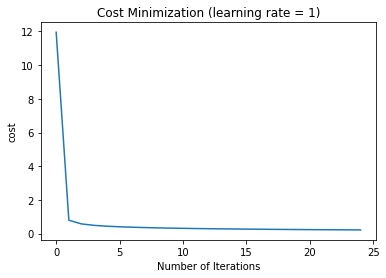

In [21]:
# Plotting cost minimization
_costs = summary["costs"]
_costs = np.squeeze(_costs)
plt.title("Cost Minimization (learning rate = 1)")
plt.xlabel("Number of Iterations")
plt.ylabel("cost")
plt.plot(_costs)
plt.show()

**Example of a false prediction and a true prediction**

Example of a false prediction
Predicted:  [5]
Actual:  [9]


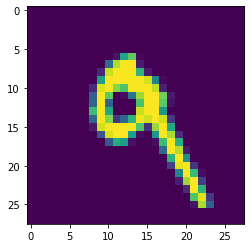

In [67]:
# False prediction
print ("Example of a false prediction")
image = test_images[:, 7:8]
_prediction = predict(summary["W1"], summary["b1"], summary["W2"], summary["b2"], image)
print ("Predicted: ", _prediction)
img = image.reshape(28,28) * 255
img = Image.fromarray(img.astype(np.uint8))
img.save("test.jpg")
plt.imshow(img)
print ("Actual: ", np.argmax(test_labels[:, 7:8], axis=0))
plt.show()

Example of a true prediction
Predicted:  [7]
Actual:  [7]


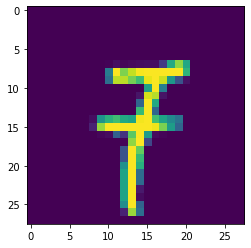

In [68]:
# True prediction
print ("Example of a true prediction")
image = test_images[:, 960:961]
_prediction = predict(summary["W1"], summary["b1"], summary["W2"], summary["b2"], image)
print ("Predicted: ", _prediction)
img = image.reshape(28,28) * 255
img = Image.fromarray(img.astype(np.uint8))
img.save("test.jpg")
plt.imshow(img)
print ("Actual: ", np.argmax(test_labels[:, 960:961], axis=0))
plt.show()

**DISCUSSION**

**Accuracy**

The model produced an overall accuracy of 94% for the training data (91% + for each digit). The learning curve also demonstrates that the cost function was being minimized. Furthermore, the classification reports shows only a slight difference between the train accuracy (94%) and the test accuracy (92%), which implies that the model does not have overfitting issues. 

Running the logistic regression model 10 times for each digit in the first part of this project had produced slightly better accuracies (more than 93% train and test accuracies for each digit). However, the imbalance in the dataset caused by having to accomodate binary classification for each digit had made the accuracies not so trustworthy. In this experiment, however, the preprocessing did not have to distort the balance of the dataset in any way (as shown in the support column of classification reports). The distribution of datapoints was uniform across all 10 labels.

Therefore, the accuracies obtained from this experiment are better and trustworthy, free from issues such as overfitting and data imbalance.

**Learning Rate and Cost**

The first part of this project had performed well with a learning rate of 0.005 over 2000 iterations. However, it was observed (after trying with different values for learning rates) that this neural network performed better with a faster learning rate (1) optimized over 2500 iterations. Initially, the number of iterations was set to 2000, but by increasing it to 2500, it enabled the cost to go further low without diverging, producing better accuracies. 

Slower learning rates of 0.05 or less severely impacted the accuracy, bringing it down to less than 80%. It was because, for a realistic number of iterations (training time wise), the cost could not descend enough with a slow learning rate.

The utility of using gradient descent is in its ability to know when to take bigger steps and when to take smaller ones while fine tuning the parameters. Choosing a learning rate of 1 in this experiment achieved that. The learning curve shows how after the first 100 iterations the cost descended sharply, then started approaching zero very slowly and gradually for the remaining (2400) iterations, letting the neurons subtly capture the relationship between the provided training images and the corresponding labels. 

For part 1, the learning curve (for learning rate = 0.005) was less abrupt for the first 200 iterations. It started with a figure less than zero, which is different from this experiment's curve (starting from ~11). The cost (part 1) was also minimized below 0.20 for each digit, producing slightly better accuracy, but we have already pointed out the problem with that flavour of accuracy. 

**Training Time**

The two-layer neural network of this experiment had the input layer that comprised 784 nodes, the hidden layer 64 nodes, and the output layer 10 nodes. The training time (2500 iterations) was ~ 4462 seconds (~ 74 minutes), which is huge. It had not taken more than 25 minutes to run 10 separate logistic regressions (2000 iterations each) in part 1. The added hidden layer and more nodes in the output layer significantly increased the training time.

**Other Trends**

**High Performing Digits** (more than 95% accuracies)

Train: `0 1 6 7` 

Test: `0 1`

These digits were also being predicted relatively well with unsupervised learning (project 1) and logistic regression (project 2, part 1). 

**Low Performing Digits** (85 to 91% accuracies)

Train: `3 5 8 9` 

Test: `2 3 5 8 9`

Digit 5 has been the hardest one to train with all the classification methods we have learned in this class so far. It always produced the lowest training accuracy and even worse testing accuracy.

It can be observed from the confusion matrices (test and train) how low performing digits are related. `3 5 and 8` are being confused for each other. The confusion matrices show that the wrong predictions for any one of these digits were mostly as a result of being mistaken for the other two. `4 7 and 9` demonstrated similar behaviour of being confused for one another. These trends are also consistent with part 1.

Perhaps, applying a better normalization technique to these digits can improve the model. For example, the example of a false prediction (in the results section) shows how the handwritten digit 9 was titled. Now, the same image was straightened by rotating it by - 30 degrees (as shown below), after which it got predicted correctly.

The results also resonate with our visual perception of different digits. For example, digits 3, 5, and 8 look similar; one can be transformed into another by changing a few pixel values. The model might not have been atuned well enough to detect these subtleties. On the other hand, unique digits such as 0 and 1 were rarely being confused for one another.

Overall, the two-layer neural network performed very well producing an  accuracy of more than 92% in average for the test and the train dataset.


**Previously falsely predicted image predicting true after rotating**

Example of a true prediction (previously predicted false)
Predicted:  [9]
Actual:  [9]


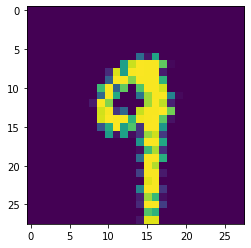

In [75]:
# True prediction after rotating
print ("Example of a true prediction (previously predicted false)")
image = test_images[:, 7:8]
print ("Predicted: ", _prediction)
img = image.reshape(28,28) * 255
img = Image.fromarray(img.astype(np.uint8))
img = img.rotate(-30)
image = np.array(img).reshape(28*28, 1)/255
_prediction = predict(summary["W1"], summary["b1"], summary["W2"], summary["b2"], image)
img.save("test.jpg")
plt.imshow(img)
print ("Actual: ", np.argmax(test_labels[:, 7:8], axis=0))
plt.show()

**Acknowledgements**



*   Andrew Ng's Videos
*   Prof. Pauca for explaining the cost function after class
*   StatQuest's YouTube channel for explaining gradient descent in details

